# Różniczkowanie numeryczne – wprowadzenie

Różniczkowanie numeryczne pozwala nam przybliżać pochodne funkcji w punktach, gdy nie znamy ich analitycznie lub chcemy je szybko policzyć na komputerze. Istnieje kilka prostych metod różniczkowania skończonego:

- **Forward Difference (różnica w przód)**  
- **Backward Difference (różnica w tył)**  
- **Central Difference (różnica centralna)**

Metoda **forward difference** jest najprostsza: przybliżamy pochodną jako zmianę wartości funkcji na małym kroku do przodu. Wzór wygląda tak:

$$
f'(x) \approx \frac{f(x+h) - f(x)}{h}
$$

Chociaż jest łatwa do zastosowania, **nie zawsze jest najlepszym wyborem**. Dlaczego?  
1. Jest dokładna tylko do pierwszego rzędu, co oznacza, że błąd maleje powoli przy zmniejszaniu kroku \(h\).  
2. W porównaniu z metodą centralną jest bardziej podatna na błędy numeryczne, zwłaszcza gdy \(h\) jest bardzo małe.  
3. Może nie uwzględniać symetrii funkcji, co prowadzi do przesunięć w przybliżeniu pochodnej.

W dalszej części notebooka przyjrzymy się wszystkim trzem metodom, obliczymy pochodne funkcji $\sin(x)$ i zobaczymy, jak różnią się wyniki w praktyce.

Zaimportujmy na początku potrzebne biblioteki i zdefiniujmy funkcję $\sin(x)$ wraz z jej dokłądną pochodną (dla porównania).

In [23]:
# Import potrzebnych bibliotek
import numpy as np
import matplotlib.pyplot as plt

# Funkcja testowa
def f(x):
    return np.sin(x)

# Dokładna pochodna funkcji testowej
def f_prime_exact(x):
    return np.cos(x)

# Przykładowy wektor punktów do obliczeń
x = np.linspace(0, np.pi, 1000000)
h = 0.01  # przykładowy krok

# Trzy metody różniczkowania numerycznego

W tym notebooku będziemy przybliżać pochodną funkcji w punktach korzystając z trzech popularnych metod:

1. **Forward Difference (różnica w przód)**  
   Przybliżenie pochodnej liczymy jako zmianę funkcji na małym kroku do przodu:  
   $$
   f'(x) \approx \frac{f(x+h) - f(x)}{h}
   $$
   - Zalety: prosta do implementacji  
   - Wady: dokładność tylko do pierwszego rzędu, większe błędy numeryczne dla małych kroków

2. **Backward Difference (różnica w tył)**  
   Pochodną przybliżamy, patrząc na krok wstecz:  
   $$
   f'(x) \approx \frac{f(x) - f(x-h)}{h}
   $$
   - Zalety: prosta, przydatna gdy wartości funkcji w punkcie przyszłym nie są dostępne  
   - Wady: również dokładność tylko do pierwszego rzędu, błędy podobne jak w forward difference

3. **Central Difference (różnica centralna)**  
   Pochodna przybliżana jest jako średnia zmian do przodu i do tyłu:  
   $$
   f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}
   $$
   - Zalety: dokładność do drugiego rzędu, mniejsze błędy numeryczne  
   - Wady: wymaga znajomości wartości funkcji po obu stronach punktu, trochę bardziej skomplikowana w implementacji

   ---

# Zadanie: implementacja metod różniczkowania numerycznego

W tym zadaniu Twoim celem jest **zaimplementowanie trzech metod przybliżania pochodnej funkcji**:

1. **Forward Difference (różnica w przód)**  
2. **Backward Difference (różnica w tył)**  
3. **Central Difference (różnica centralna)**

Będziesz korzystać z funkcji testowej $f(x) = \sin(x)$ i sprawdzisz wyniki swoich metod w porównaniu z dokładną pochodną $f'(x) = \cos(x)$.  

**Instrukcje:**
- Dla każdej metody utwórz funkcję, która przyjmuje argumenty: funkcję `f`, punkt `x` oraz krok `h`.  
- Funkcja powinna zwracać przybliżoną pochodną w punkcie `x`.  
- Po zaimplementowaniu wszystkich metod, porównamy ich wyniki i narysujemy wykresy, aby zobaczyć różnice.

In [24]:
# Forward Difference
def forward_difference(f, x, h):
    return (f(x + h) - f(x)) / h

# Backward Difference
def backward_difference(f, x, h):
    return (f(x) - f(x - h)) / h

# Central Difference
def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

Teraz przeprowadzamy obliczenia.

In [25]:
y_forward = forward_difference(f, x, h)
y_backward = backward_difference(f, x, h)
y_central = central_difference(f, x, h)
y_exact = f_prime_exact(x)

# Wizualizacja wyników

Teraz, gdy mamy już zaimplementowane trzy metody różniczkowania numerycznego, chcemy **porównać ich wyniki wizualnie**.  

Wykresy pozwolą nam zobaczyć:
- jak różnią się przybliżone pochodne od dokładnej pochodnej $f'(x) = \cos(x)$,
- która metoda jest bardziej dokładna,
- wpływ kroku $h$ na jakość przybliżenia.  

Najpierw stworzymy wykres w **normalnej skali**, obejmujący całą dziedzinę $x \in [0, 2\pi]$.  
Później zwiększymy skalę osi y lub przybliżymy fragment wykresu, aby uwidocznić **nawet drobne różnice między metodami**.

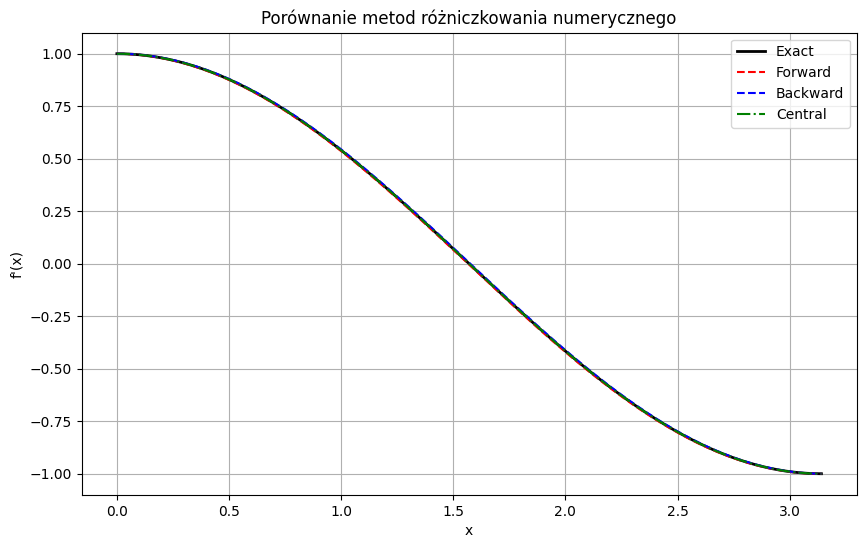

In [26]:
# Rysowanie wykresu porównawczego
plt.figure(figsize=(10, 6))
plt.plot(x, y_exact, label='Exact', color='black', linewidth=2)
plt.plot(x, y_forward, label='Forward', color='red', linestyle='--')
plt.plot(x, y_backward, label='Backward', color='blue', linestyle='--')
plt.plot(x, y_central, label='Central', color='green', linestyle='-.')

plt.title("Porównanie metod różniczkowania numerycznego")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.legend()
plt.grid(True)
plt.show()

### Powiększenie wykresu w okolicach punktu \( x = 2 \)

W tej części ponownie narysujemy wszystkie krzywe: dokładną pochodną oraz trzy metody numeryczne. Tym razem jednak skupimy się na **wąskim fragmencie wykresu wokół punktu \( x = 2 \)**. Na szerokiej skali różnice między metodami były prawie niewidoczne, dlatego teraz je powiększymy.

Ponieważ chcemy trzymać się możliwie prostych narzędzi programistycznych, **nie będziemy używać masek logicznych z NumPy**.  
Zamiast tego stworzymy nowe listy `x_zoom` i `y_zoom`, wypełniając je tylko tymi wartościami \( x \), które spełniają warunek:

 $$ 1.5 \le x \le 2.5 $$

Taki sposób pozwala w przejrzysty sposób zobaczyć, jak wybieramy fragment wykresu. Po przygotowaniu tych list narysujemy wykres ponownie, aby wyraźnie porównać jakość metod różniczkowania numerycznego w powiększeniu.

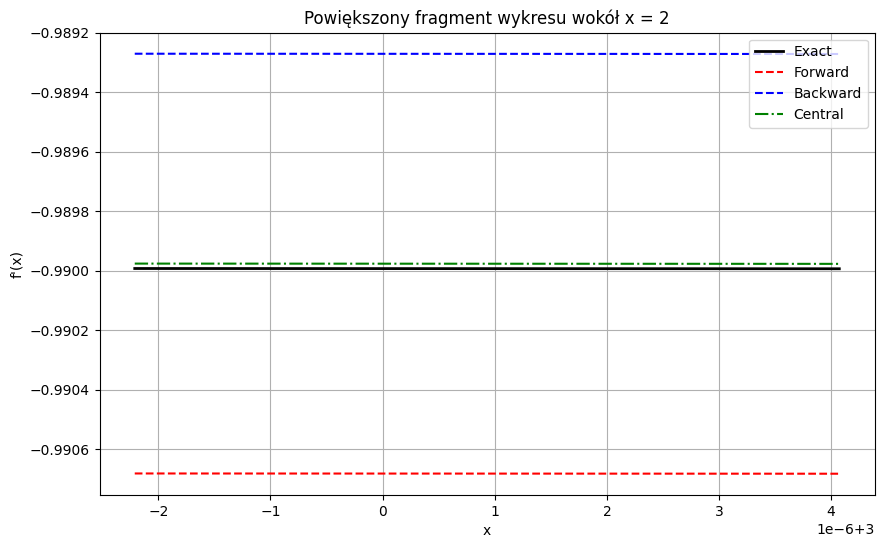

In [27]:
# Prosty wykres powiększony wokół x = 2
plt.figure(figsize=(10, 6))

# Tworzymy zakres blisko x = 2
x_zoom = []
y_exact_zoom = []
y_forward_zoom = []
y_backward_zoom = []
y_central_zoom = []

for xi, ye, yf, yb, yc in zip(x, y_exact, y_forward, y_backward, y_central):
    if 2.999995 <= xi <= 3.000005:
        x_zoom.append(xi)
        y_exact_zoom.append(ye)
        y_forward_zoom.append(yf)
        y_backward_zoom.append(yb)
        y_central_zoom.append(yc)

plt.plot(x_zoom, y_exact_zoom, label='Exact', color='black', linewidth=2)
plt.plot(x_zoom, y_forward_zoom, label='Forward', color='red', linestyle='--')
plt.plot(x_zoom, y_backward_zoom, label='Backward', color='blue', linestyle='--')
plt.plot(x_zoom, y_central_zoom, label='Central', color='green', linestyle='-.')

plt.title("Powiększony fragment wykresu wokół x = 2")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.legend()
plt.grid(True)
plt.show()

### Zadanie: Porównanie metod różniczkowania przy coraz większym powiększeniu

W poprzednim kroku powiększyliśmy wykres do zakresu \( 1.5 \le x \le 2.5 \).  
Teraz samodzielnie zrób jeszcze większe powiększenia, aby zobaczyć, jak zachowują się metody numeryczne przy coraz bardziej szczegółowym podglądzie.

#### Twoje zadanie (wystarczy zmodyfikować kod powyżej):

1. Zmień zakres powiększenia na:
    $$ 1.95 \le x \le 2.05 $$
2. Następnie jeszcze bardziej zawęź zakres, np.:
   $$ 1.995 \le x \le 2.005 $$
3. Jeśli chcesz, możesz spróbować jeszcze mniejszych przedziałów (np. szerokości $ 0.001 $ lub nawet $ 0.0005 $).

#### Co masz zrobić w każdej z tych sytuacji?

- Utwórz nowe listy `x_zoom` (i odpowiadające im listy rezultatów) zawierające tylko punkty z wybranego zakresu.
- Narysuj wykres wszystkich czterech funkcji: dokładnej pochodnej, forward, backward oraz central.
- Zaobserwuj i opisz, jak zmienia się różnica między metodami numerycznymi przy coraz większym powiększeniu.

#### Pytania pomocnicze:

- Która metoda pozostaje najbliżej dokładnej pochodnej nawet przy bardzo dużym powiększeniu?
- Czy widzisz, że metoda forward lub backward zaczyna "odjeżdżać" od rozwiązania dokładnego?
- Jak zmienia się wpływ kroku \( h \) na jakość przybliżenia?

Postaraj się odpowiedzieć na te pytania po wykonaniu wykresów.

### Zadanie dodatkowe (dla chętnych): numeryczne znalezienie ekstremum funkcji

W praktyce często interesuje nas nie tylko wartość pochodnej, lecz także **punkt, w którym pochodna znika**. Takie miejsca to potencjalne **ekstrema** funkcji (maksima lub minima). Można je znaleźć również numerycznie, korzystając z metod różniczkowania poznanych na zajęciach.

#### Twoje zadanie:

1. Wybierz jedną z metod numerycznego różniczkowania:  
   - forward difference,  
   - backward difference,  
   - central difference.

2. Wygeneruj siatkę punktów $ x $ na pewnym przedziale (np. $ 0 \le x \le 10 $).

3. Oblicz numeryczną pochodną dla wybranej funkcji, np.  
   $$
   f(x) = \sin(x) + 0.1x.
   $$

4. Znajdź punkt, w którym pochodna zmienia znak:
   - z dodatniej na ujemną — możliwe maksimum,  
   - z ujemnej na dodatnią — możliwe minimum.

5. Zaznacz znaleziony punkt na wykresie funkcji i sprawdź, czy wygląda on na ekstremum.

Znalezione ekstremum:
 x = 1.7750000000000001


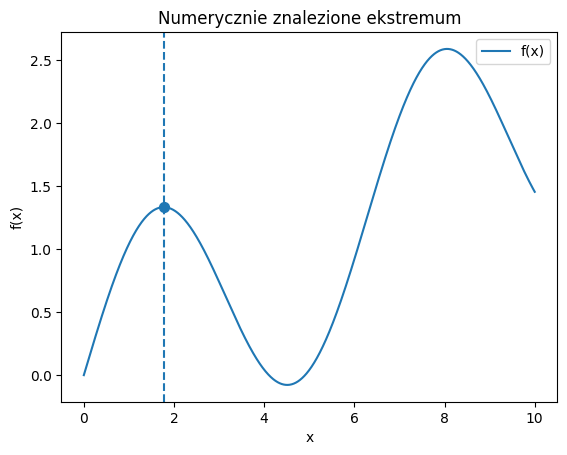

In [32]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Funkcja
def f(x):
    return math.sin(x) + 0.2*x

# Metoda central difference
def derivative_central(f, x, h=1e-3):
    return (f(x+h) - f(x-h)) / (2*h)

# Siatka punktów
xs = np.linspace(0, 10, 2001)   # gęsta siatka
ds = []                         # lista wartości pochodnej

# Obliczenie pochodnej na siatce
for x in xs:
    ds.append(derivative_central(f, x))

# Znalezienie punktu zmiany znaku pochodnej
extremum_x = None

for i in range(1, len(xs)):
    if ds[i-1] < 0 and ds[i] > 0:
        extremum_x = xs[i]
        break
    if ds[i-1] > 0 and ds[i] < 0:
        extremum_x = xs[i]
        break

print("Znalezione ekstremum:")
print(" x =", extremum_x)

# Wykres funkcji i ekstremum
ys = [f(x) for x in xs]

plt.plot(xs, ys, label="f(x)")
if extremum_x is not None:
    plt.scatter([extremum_x], [f(extremum_x)], s=50)
    plt.axvline(extremum_x, linestyle="--")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Numerycznie znalezione ekstremum")
plt.show()